<a href="https://colab.research.google.com/github/Rini43/Case-Study-on-Supervised-Learning/blob/main/Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clone the GitHub

In [120]:
# Clone the GitHub repository into the Google Colab environment

!git clone https://github.com/Rini43/Case-Study-on-Supervised-Learning

fatal: destination path 'Case-Study-on-Supervised-Learning' already exists and is not an empty directory.


# Libraries

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Read the Data

In [122]:
filepath = "/content/Case-Study-on-Supervised-Learning/heart_disease (1).csv"
df_heart = pd.read_csv(filepath)
df_heart.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# EDA

In [123]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [124]:
df_heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [125]:
df_heart.shape

(1025, 14)

In [126]:
df_heart.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

# Preprocessing

In [127]:
# Check the duplicates
duplicates = df_heart.duplicated().sum()
duplicates

np.int64(723)

In [128]:
# Drop the duplicates
df_heart = df_heart.drop_duplicates()

In [129]:
# Check for the missing values
df_heart.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [130]:
df_heart.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [131]:
df_heart.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


# Correlation matrix

In [132]:
corr_matrix = df_heart.corr()
corr_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


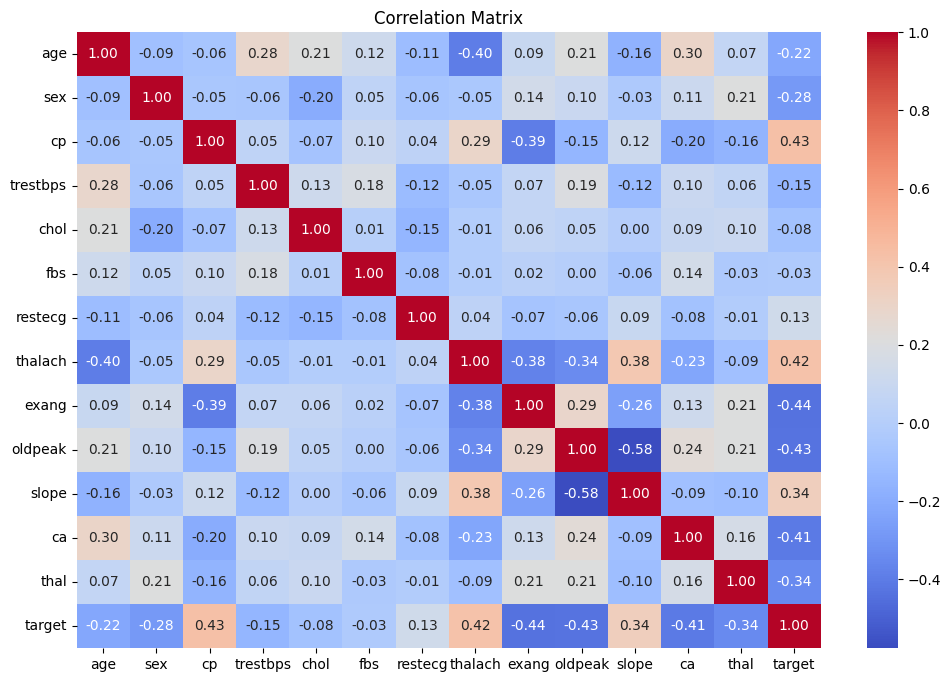

In [133]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

# Mutual Information

In [156]:
# Features
X = df_heart.drop('target', axis=1)

# Target
y = df_heart['target']

# Mutual Information
mi_scores = mutual_info_classif(
    X, y, random_state=42)

mi = pd.Series(mi_scores, index=X.columns)
mi = mi.sort_values(ascending=False)
mi

,0
thal_2,0.151113
thal_3,0.112629
ca,0.110107
slope,0.094065
oldpeak,0.082638
cp_2,0.072762
exang,0.071810
thalach,0.059233
chol,0.058425
restecg_1,0.016476


# Outliers

In [135]:
Q1 = df_heart.quantile(0.25)
Q3 = df_heart.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df_heart < (Q1 - 1.5 * IQR)) | (df_heart > (Q3 + 1.5 * IQR))).sum()
outliers

,0
age,0
sex,0
cp,0
trestbps,9
chol,5
fbs,45
restecg,0
thalach,1
exang,0
oldpeak,5


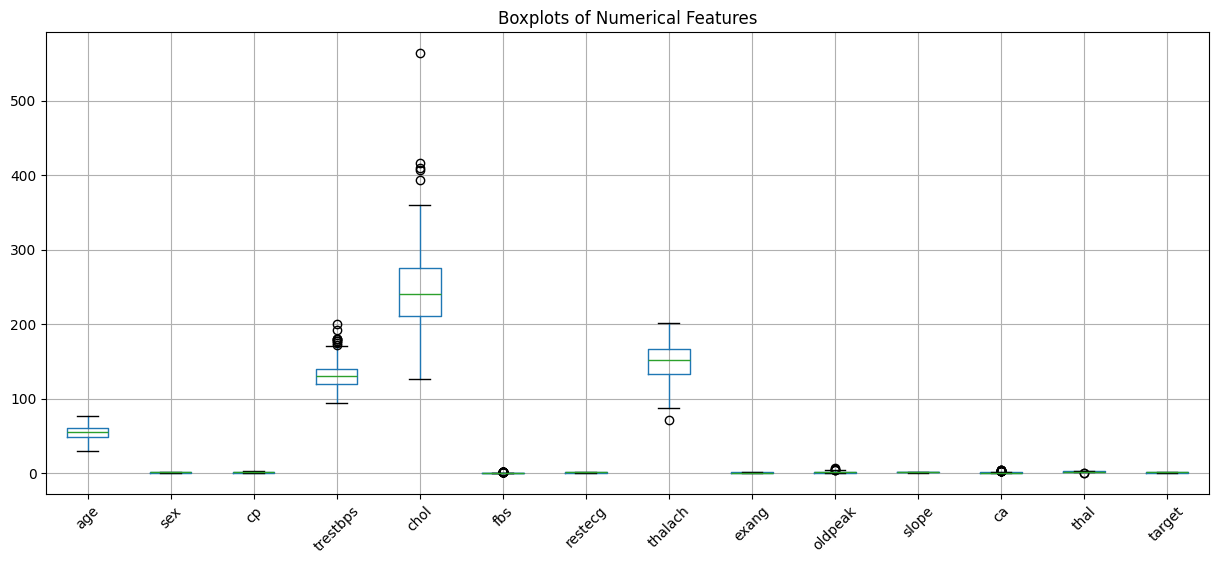

In [136]:
df_heart.boxplot(figsize=(15,6), rot=45)
plt.title("Boxplots of Numerical Features")
plt.show()

In [137]:
cat_cols = ['sex','cp','fbs','restecg','exang',
    'slope','ca','thal','target']

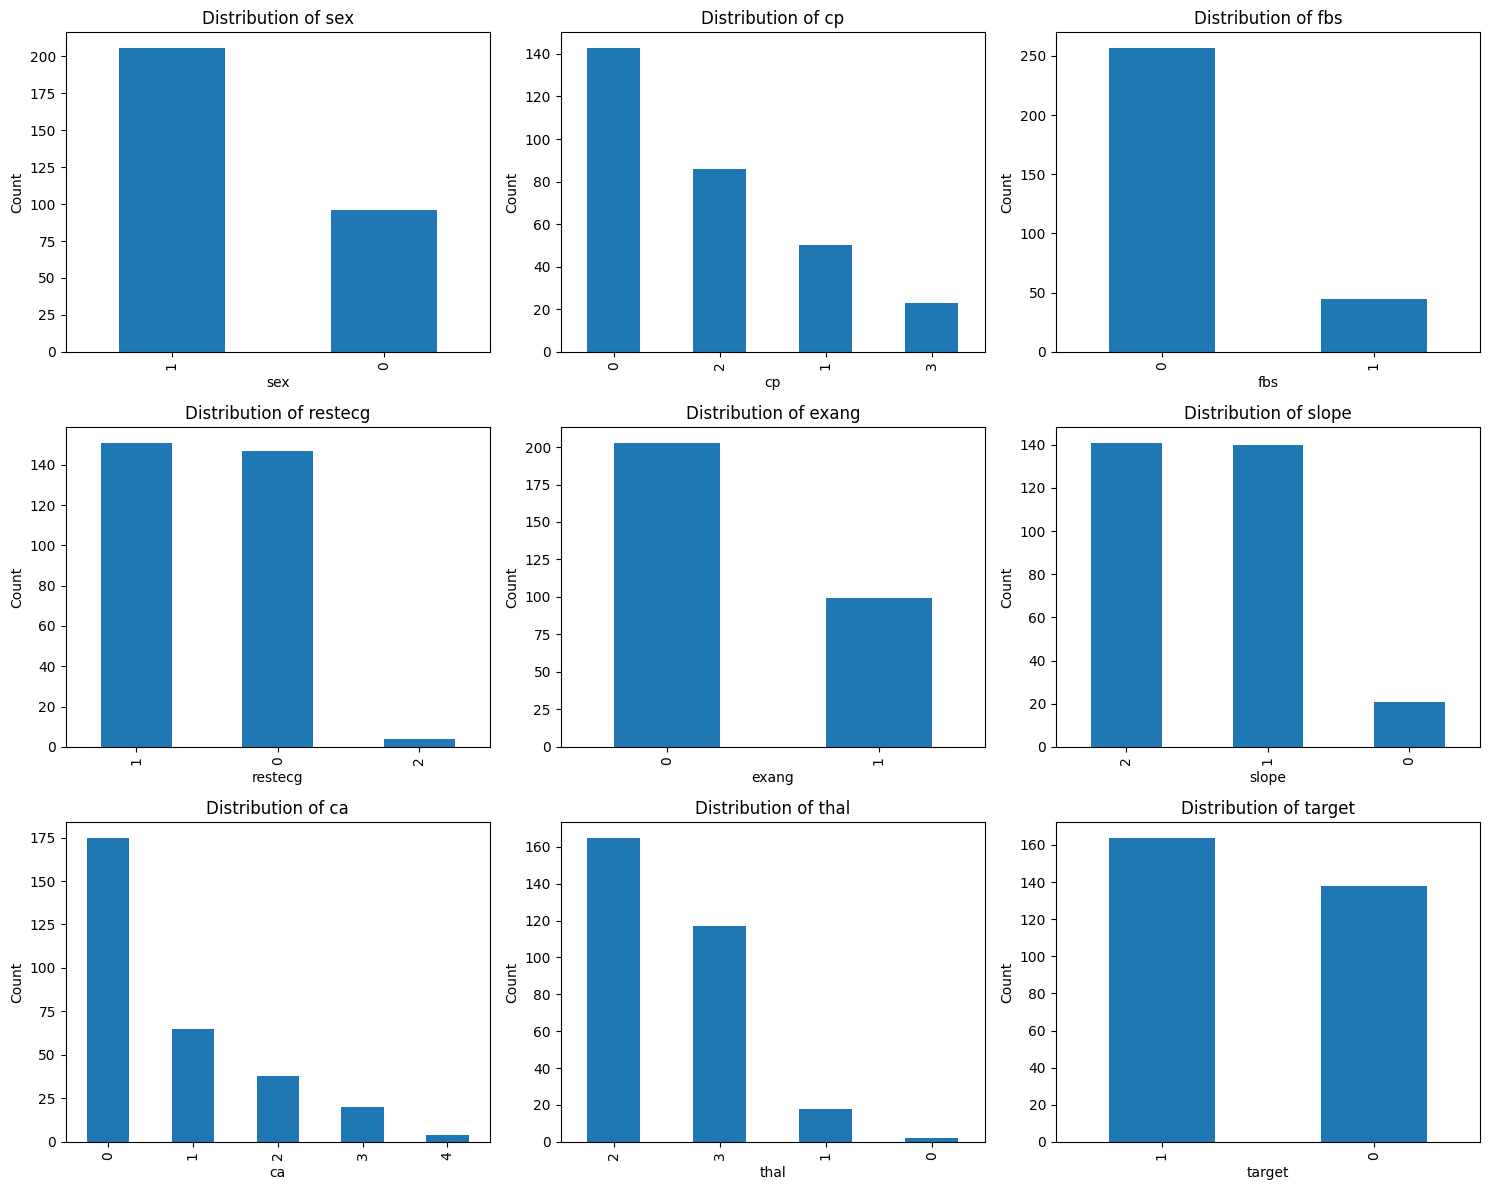

In [138]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df_heart[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [139]:
num_cols = df_heart.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df_heart[col] = df_heart[col].fillna(df_heart[col].median())

In [140]:
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal','target']

for col in cat_cols:
    df_heart[col] = df_heart[col].fillna(df_heart[col].mode()[0])

# Handling the Outliers

In [141]:
num_features = ['trestbps', 'chol', 'thalach', 'oldpeak']

In [142]:
for col in num_features:

    Q1 = df_heart[col].quantile(0.25)
    Q3 = df_heart[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_heart[col] = df_heart[col].clip(lower, upper)

In [143]:
df_heart[['sex','fbs']].head()

# It is already binary encoded

,sex,fbs
0,1,0
1,1,1
2,1,0
3,1,0
4,0,1


# One-hot Encoding

In [144]:
# Using one-hot encoding for multi-category variables (chest pain type, resting electrocardiographic results, thal).

one_hot_cols = ['cp', 'restecg', 'thal']
df_heart = pd.get_dummies(df_heart, columns=one_hot_cols,
    drop_first=True)

# Scaling

In [145]:
scaler = StandardScaler()
scale_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']
df_heart[scale_cols] = scaler.fit_transform(df_heart[scale_cols])

# Regression

In [146]:
# Predicting the chol
# Features and Target
X_reg = df_heart.drop('chol', axis=1)
y_reg = df_heart['chol']

# Train-Test Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,y_reg,test_size=0.2,random_state=42)

print("Training Features Shape:", X_train_reg.shape)
print("Testing Features Shape :", X_test_reg.shape)
print("Training Target Shape  :", y_train_reg.shape)
print("Testing Target Shape   :", y_test_reg.shape)

Training Features Shape: (241, 18)
Testing Features Shape : (61, 18)
Training Target Shape  : (241,)
Testing Target Shape   : (61,)


# Classification

In [147]:
# Predicting the target
# Features and Target
X_cls = df_heart.drop('target', axis=1)
y_cls = df_heart['target']

# Train-Test Split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,y_cls,test_size=0.2,random_state=42,stratify=y_cls)

print("Training Features Shape:", X_train_cls.shape)
print("Testing Features Shape :", X_test_cls.shape)
print("Training Target Shape  :", y_train_cls.shape)
print("Testing Target Shape   :", y_test_cls.shape)

Training Features Shape: (241, 18)
Testing Features Shape : (61, 18)
Training Target Shape  : (241,)
Testing Target Shape   : (61,)


# Ml Model

## Regression

### Linear Regression

In [148]:
# Train model
linear = LinearRegression()
linear.fit(X_train_reg, y_train_reg)

# Prediction
y_pred_linear = linear.predict(X_test_reg)

# Evaluation
print("Linear Regression")
print("MAE :", mean_absolute_error(y_test_reg, y_pred_linear))
print("MSE :", mean_squared_error(y_test_reg, y_pred_linear))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_linear)))
print("R2 Score:", r2_score(y_test_reg, y_pred_linear))

Linear Regression
MAE : 0.7148000551934311
MSE : 0.8331783127666882
RMSE: 0.9127860169649227
R2 Score: -0.17033337713500396


### Support Vector Regression (SVR)

In [149]:
# Train model
svr = SVR(kernel='rbf')
svr.fit(X_train_reg, y_train_reg)

# Prediction
y_pred_svr = svr.predict(X_test_reg)

# Evaluation
print("Support Vector Regression")
print("MAE :", mean_absolute_error(y_test_reg, y_pred_svr))
print("MSE :", mean_squared_error(y_test_reg, y_pred_svr))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_svr)))
print("R2 Score:", r2_score(y_test_reg, y_pred_svr))

Support Vector Regression
MAE : 0.6575786137247279
MSE : 0.6831142753394388
RMSE: 0.8265072748254784
R2 Score: 0.04045577690041313


### Random Forest Regressor

In [150]:
# Train model
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)

# Prediction
y_pred_rf = rf_reg.predict(X_test_reg)

# Evaluation
print("Random Forest Regressor")
print("MAE :", mean_absolute_error(y_test_reg, y_pred_rf))
print("MSE :", mean_squared_error(y_test_reg, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)))
print("R2 Score:", r2_score(y_test_reg, y_pred_rf))

Random Forest Regressor
MAE : 0.6945620703276647
MSE : 0.7994918802498129
RMSE: 0.8941430983068722
R2 Score: -0.12301534721630536


## Classification

### Logistic Regression

In [151]:
# Train model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_cls, y_train_cls)

# Prediction
y_pred_log = log_model.predict(X_test_cls)

# Evaluation
print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test_cls, y_pred_log))
print("Precision:", precision_score(y_test_cls, y_pred_log))
print("Recall   :", recall_score(y_test_cls, y_pred_log))
print("F1 Score :", f1_score(y_test_cls, y_pred_log))

Logistic Regression
Accuracy : 0.8524590163934426
Precision: 0.875
Recall   : 0.8484848484848485
F1 Score : 0.8615384615384616


### K-Nearest Neighbors (KNN)

In [152]:
# Train model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_cls, y_train_cls)

# Prediction
y_pred_knn = knn.predict(X_test_cls)

# Evaluation
print("K-Nearest Neighbors")
print("Accuracy :", accuracy_score(y_test_cls, y_pred_knn))
print("Precision:", precision_score(y_test_cls, y_pred_knn))
print("Recall   :", recall_score(y_test_cls, y_pred_knn))
print("F1 Score :", f1_score(y_test_cls, y_pred_knn))

K-Nearest Neighbors
Accuracy : 0.7704918032786885
Precision: 0.7714285714285715
Recall   : 0.8181818181818182
F1 Score : 0.7941176470588235


### Random Forest Classifier

In [153]:
# Train model
rf_cls = RandomForestClassifier(n_estimators=200, random_state=42)
rf_cls.fit(X_train_cls, y_train_cls)

# Prediction
y_pred_rf_cls = rf_cls.predict(X_test_cls)

# Evaluation
print("Random Forest Classifier")
print("Accuracy :", accuracy_score(y_test_cls, y_pred_rf_cls))
print("Precision:", precision_score(y_test_cls, y_pred_rf_cls))
print("Recall   :", recall_score(y_test_cls, y_pred_rf_cls))
print("F1 Score :", f1_score(y_test_cls, y_pred_rf_cls))

Random Forest Classifier
Accuracy : 0.8032786885245902
Precision: 0.8181818181818182
Recall   : 0.8181818181818182
F1 Score : 0.8181818181818182


# Regression Results Summary

In [154]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

regression_results = pd.DataFrame({
    "Model": ["Linear Regression", "Support Vector Regression", "Random Forest Regressor"],
    "MAE": [
        mean_absolute_error(y_test_reg, y_pred_linear),
        mean_absolute_error(y_test_reg, y_pred_svr),
        mean_absolute_error(y_test_reg, y_pred_rf)
    ],
    "MSE": [
        mean_squared_error(y_test_reg, y_pred_linear),
        mean_squared_error(y_test_reg, y_pred_svr),
        mean_squared_error(y_test_reg, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_reg, y_pred_linear)),
        np.sqrt(mean_squared_error(y_test_reg, y_pred_svr)),
        np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
    ],
    "R² Score": [
        r2_score(y_test_reg, y_pred_linear),
        r2_score(y_test_reg, y_pred_svr),
        r2_score(y_test_reg, y_pred_rf)
    ]
})

regression_results

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,0.714800,0.833178,0.912786,-0.170333
1,Support Vector Regression,0.657579,0.683114,0.826507,0.040456
2,Random Forest Regressor,0.694562,0.799492,0.894143,-0.123015


Best Model: Support Vector Regression (SVR)

Reason:

* It has the lowest MAE (0.6575).
* It has the lowest MSE (0.6831).
* It has the lowest RMSE (0.8265).
* It has the highest R² Score (0.0404).

# Classification Results Summary

In [155]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "K-Nearest Neighbors", "Random Forest Classifier"],
    "Accuracy": [
        accuracy_score(y_test_cls, y_pred_log),
        accuracy_score(y_test_cls, y_pred_knn),
        accuracy_score(y_test_cls, y_pred_rf_cls)
    ],
    "Precision": [
        precision_score(y_test_cls, y_pred_log),
        precision_score(y_test_cls, y_pred_knn),
        precision_score(y_test_cls, y_pred_rf_cls)
    ],
    "Recall": [
        recall_score(y_test_cls, y_pred_log),
        recall_score(y_test_cls, y_pred_knn),
        recall_score(y_test_cls, y_pred_rf_cls)
    ],
    "F1 Score": [
        f1_score(y_test_cls, y_pred_log),
        f1_score(y_test_cls, y_pred_knn),
        f1_score(y_test_cls, y_pred_rf_cls)
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.852459,0.875000,0.848485,0.861538
1,K-Nearest Neighbors,0.770492,0.771429,0.818182,0.794118
2,Random Forest Classifier,0.803279,0.818182,0.818182,0.818182


Best Model: Logistic Regression

Reason:

* Highest Accuracy: 85.24%
* Highest Precision: 87.50%
* Highest Recall: 84.84%
* Highest F1 Score: 86.15%